# Chapter 2. 데이터 다루기
---

## 02-1 훈련 세트와 테스트 세트
---

### 지도학습과 비지도 학습
머신러닝 알고리즘은 크게 두 가지로 나뉜다 :
- 지도 학습(supervised learning)
- 비지도 학습(unsupervised learning)

<br>

이 중 지도 학습은 훈련하기 위한 데이터와 정답이 필요하다.
- 여기서 데이터를 입력(input), 정답을 타깃(target)이라고 하며,
- 이 둘을 합쳐 훈련 데이터(training data)라고 한다.

<br>

지도 학습은 정답(타깃)이 있기 때문에, 정답을 맞히는 것을 학습한다.
반면, 비지도 학습은 타깃 없이 입력 데이터만을 사용한다.
-   정답을 활용하지 않기 때문에 무언가를 맞히는 것 대신, 데이터를 잘 파악하거나 변형하는 데 도움을 준다.

---

### 훈련 세트와 테스트 세트
학생의 성적을 평가할 때 연습 문제와 시험 문제가 달라야 올바르게 평가할 수 있는 것 처럼,\
머신러닝 알고리즘의 성능을 평가할 때에도, **훈련 데이터와 평가에 사용할 데이터가 달라야 한다.**

- 평가에 사용하는 데이터를 **테스트 세트(test set)**
- 훈련에 사용되는 데이터를 **훈련 세트(train set)**라고 한다.


In [8]:
from fontTools.varLib.interpolatableTestStartingPoint import test_starting_point
from sklearn.preprocessing import TargetEncoder

# 1장에서 사용한 생선의 길이와 무게 리스트를 준비했다.
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
               31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
               35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
               10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
               500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
               700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
               7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

# 각 생선의 길이와 무게를 하나의 리스트로 담은 2차원 리스트를 만든다
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target = [1] * 35 + [0] * 14

- 여기서 하나의 생선 데이터를 우리는 **샘플(sample)**이라고 한다.
    - 위의 경우에는 도미 35마리 와 빙어 14마리 이므로, 샘플이 49개 있는 것이다. (특성은 길이와 무게)
    - 이 중 우리는 35개를 훈련 세트, 14개를 테스트 세트로 사용한다.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

# 훈련 세트로 사용할 0 ~ 34 번 인덱스
train_input = fish_data[:35]
train_target = fish_target[:35]

# 테스트 세트로 사용할 35 ~ 48 번 인덱스
test_input = fish_data[35:]
test_target = fish_target[35:]

kn.fit(train_input, train_target)
kn.score(test_input, test_target)

0.0

- 이에 대한 결과로 정확도가 "0.0"이 나오게 된다.. 왜?

---

### 샘플링 편향
앞서 나누었던 테스트 세트에는 빙어만 들어가 있었다.\
따라서 빙어 없이 모델을 훈련시켰기 때문에 빙어를 올바르게 분류할 수 없었던 것이다.

<br>

상식적으로 훈련하는 데이터와 테스트하는 데이터에는 도미와 빙어가 골고루 섞여 있어야 한다.\
그렇지 않으면 샘플링이 한쪽으로 치우지게 되고, 이를 **샘플링 편향(sampling bias)** 라고 한다.

<br>

해당 작업들을 간편하게 처리하기 위한 라이브러리 넘파이에 대해서 알아보자

---

### 넘파이


In [11]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

print(input_arr)
print(input_arr.shape)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]
(49, 2)


생선 데이터를 넘파이 배열로 준비했으므로 랜덤하게 샘플을 선택해 훈련 세트와 테스트 세트를 만들 차례이다.
- 이를 위해 배열을 섞은 후에 나누느 방식 대신에 무작위로 샘플을 고르는 방식을 사용한다.
- 한 가지 주의할 점은, `input_arr`과 `target_arr`의 같은 위치는 함께 선택되어야 한다는 것이다.

In [45]:
"""
넘파이에서 무작위 결과를 만드는 함수들은 실행할 때마다 다른 결과를 만든다.
따라서, 일정한 결과를 얻으려면 초기에 랜덤 시드(random seed)를 지정해주면 된다.
"""
np.random.seed(42) # 이게 없으면 출력마다 결과가 바뀐다.
index = np.arange(49)
np.random.shuffle(index)

print(index)

train_input = input_arr[index[:35], :]
train_target = target_arr[index[:35]]

test_input = input_arr[index[35:], :]
test_target = target_arr[index[35:]]


[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


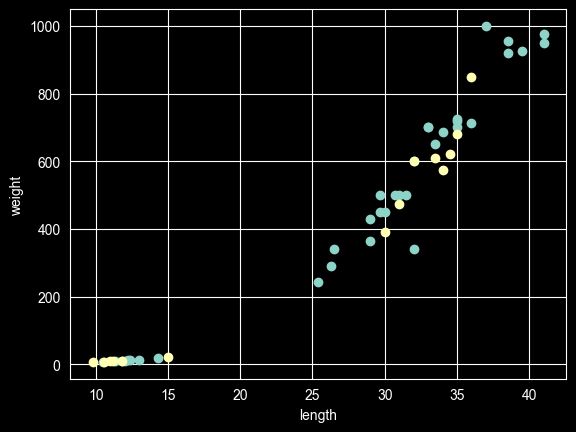

In [43]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:, 0], train_input[:,1])
plt.scatter(test_input[:, 0], test_input[:, 1])

plt.xlabel("length")
plt.ylabel("weight")

plt.show()


---

### 두 번째 머신러닝 프로그램
앞서 만든 새로운 훈련 세트와 테스트 세트로 모델을 훈련시켜 본다.

In [52]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target) # 1.0 => 100%의 정확도를 가지게 되었다.

# 실제 예측
pred = kn.predict(test_input)
print(pred)
print(test_target)

[0 0 1 0 1 1 1 0 1 1 0 1 1 0]
[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


---
